# Bitácora Técnica: Detección de Deserción Estudiantil

Este notebook presenta el flujo completo para el desarrollo de un modelo de detección de deserción estudiantil, desde la carga y preprocesamiento de datos, hasta el entrenamiento, evaluación y la implementación de un diagnóstico individual. Cada sección y fragmento de código está comentado para facilitar su comprensión y replicabilidad.

In [23]:
# FASE 1: CARGA DE DATOS INICIAL
# Leer el archivo Excel que contiene el dataset de deserción estudiantil.
df = pd.read_excel('Test.xlsx')

# Mostrar las primeras filas del DataFrame para una inspección inicial de los datos.
print(df.head())

  Periodo  EDAD  SEXO  ESTRATO  NATURALEZA DE COLEGIO  \
0  2018-2    22     1        1                      0   
1  2018-2    18     0        2                      0   
2  2019-1    22     0        2                      0   
3  2017-2    20     0        2                      0   
4  2019-1    19     1        1                      0   

   PUNTAJE INSCRIPCIÓN ICFES (No matriculado)  VALOR PAGADO  CALIF_ACADEMICA  \
0                                      332.00      271560.0              1.9   
1                                      337.00      486401.0             -1.1   
2                                       50.52      486401.0              0.0   
3                                      286.00      451925.0             -0.1   
4                                      198.00     2244112.0              3.7   

   CALIF_ECONOMICO  CALIF_FAMILIAR  ...  PUNTAJEINHALANTE  PUNTAJESEDANTE  \
0             -0.3            -3.8  ...                 8               3   
1              2.5    

In [24]:
# Importar librerías necesarias para la carga de datos, preprocesamiento y modelado.
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [25]:
# Leer el archivo
df = pd.read_excel('Test.xlsx')

# Ver los primeros datos para confirmar que todo está bien
print(df.head())

  Periodo  EDAD  SEXO  ESTRATO  NATURALEZA DE COLEGIO  \
0  2018-2    22     1        1                      0   
1  2018-2    18     0        2                      0   
2  2019-1    22     0        2                      0   
3  2017-2    20     0        2                      0   
4  2019-1    19     1        1                      0   

   PUNTAJE INSCRIPCIÓN ICFES (No matriculado)  VALOR PAGADO  CALIF_ACADEMICA  \
0                                      332.00      271560.0              1.9   
1                                      337.00      486401.0             -1.1   
2                                       50.52      486401.0              0.0   
3                                      286.00      451925.0             -0.1   
4                                      198.00     2244112.0              3.7   

   CALIF_ECONOMICO  CALIF_FAMILIAR  ...  PUNTAJEINHALANTE  PUNTAJESEDANTE  \
0             -0.3            -3.8  ...                 8               3   
1              2.5    

In [26]:
# Identificar y seleccionar todas las columnas numéricas del DataFrame para la normalización.
# Se excluye la columna 'Etiqueta' (variable objetivo) y 'Periodo' (identificador) de esta lista.
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Etiqueta' in columnas_numericas:
    columnas_numericas.remove('Etiqueta')

# Imprimir las columnas seleccionadas para confirmar cuáles serán normalizadas.
print("Columnas que serán normalizadas:", columnas_numericas)

Columnas que serán normalizadas: ['EDAD', 'SEXO', 'ESTRATO', 'NATURALEZA DE COLEGIO', 'PUNTAJE INSCRIPCIÓN ICFES (No matriculado)', 'VALOR PAGADO', 'CALIF_ACADEMICA', 'CALIF_ECONOMICO', 'CALIF_FAMILIAR', 'CALIF_PSICOSOCIAL', 'DEPRESIÓN', 'ANSIEDAD', 'PUNTAJETABACO', 'PUNTAJEALCOHOL', 'PUNTAJECANNABIS', 'PUNTAJECOCAINA', 'PUNTAJEANFETAMINA', 'PUNTAJEINHALANTE', 'PUNTAJESEDANTE', 'PUNTAJEALUCINOGENO', 'PUNTAJEOPIACEO', 'PUNTAJEOTRADROGA', 'estrategia_ACOMODADOR', 'estrategia_ASIMILADOR', 'estrategia_CONVERGENTE', 'estrategia_DIVERGENTE']


In [27]:
# FASE 3: PREPROCESAMIENTO DE DATOS - NORMALIZACIÓN

# 1. Instanciar el objeto StandardScaler para escalar las características.
scaler = StandardScaler()

# 2. Crear una copia del DataFrame original para almacenar los datos normalizados.
df_normalizado = df.copy()
# Aplicar el escalado (ajustar y transformar) solo a las columnas numéricas identificadas.
df_normalizado[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# 3. Mostrar las primeras filas del DataFrame con los datos ya normalizados para verificar el proceso.
print("Datos normalizados (primeras 5 filas):")
print(df_normalizado.head())

Datos normalizados (primeras 5 filas):
  Periodo      EDAD      SEXO   ESTRATO  NATURALEZA DE COLEGIO  \
0  2018-2  0.750282  0.858580 -1.113336              -0.369274   
1  2018-2 -0.643055 -1.164713 -0.015277              -0.369274   
2  2019-1  0.750282 -1.164713 -0.015277              -0.369274   
3  2017-2  0.053613 -1.164713 -0.015277              -0.369274   
4  2019-1 -0.294721  0.858580 -1.113336              -0.369274   

   PUNTAJE INSCRIPCIÓN ICFES (No matriculado)  VALOR PAGADO  CALIF_ACADEMICA  \
0                                    0.793570     -0.571926         1.171127   
1                                    0.900156     -0.362345        -0.301747   
2                                   -5.206792     -0.362345         0.238307   
3                                   -0.187021     -0.395977         0.189211   
4                                   -2.062933      1.352332         2.054852   

   CALIF_ECONOMICO  CALIF_FAMILIAR  ...  PUNTAJEINHALANTE  PUNTAJESEDANTE  \
0     

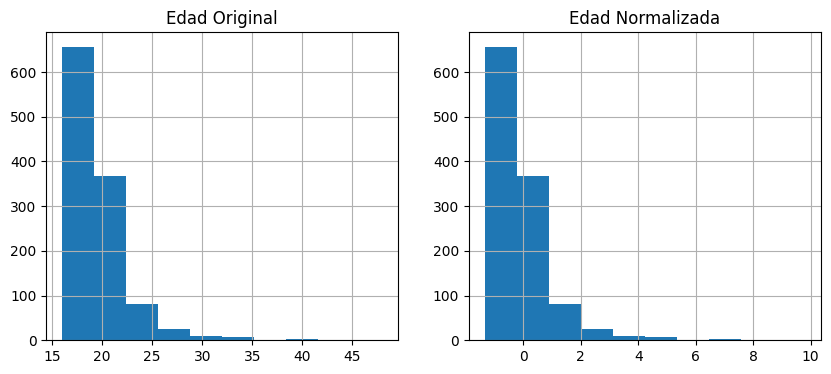

In [28]:
import matplotlib.pyplot as plt

# Visualizar la distribución de una variable (ej. 'EDAD') antes y después de la normalización.
# Esto ayuda a verificar visualmente el efecto del StandardScaler.
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
df['EDAD'].hist()
plt.title('Edad Original')

plt.subplot(1, 2, 2)
df_normalizado['EDAD'].hist()
plt.title('Edad Normalizada')
plt.show()

In [29]:
# Instalar la librería 'imbalanced-learn' para manejar el desbalance de clases con SMOTE.
!pip install imbalanced-learn

In [30]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Continuación FASE 3: PREPROCESAMIENTO DE DATOS - BALANCEO DE CLASES con SMOTE
# Supongamos que df_normalizado es el resultado del paso anterior de normalización.

# 1. Separar las características (X) de la variable objetivo (y).
# Excluir 'Etiqueta' y 'Periodo' de las características.
X = df_normalizado.drop(['Etiqueta', 'Periodo'], axis=1)
y = df_normalizado['Etiqueta']

# 2. Configurar SMOTE (Synthetic Minority Over-sampling Technique).
# random_state asegura la reproducibilidad de los resultados.
smote = SMOTE(random_state=42)

# 3. Aplicar SMOTE para generar muestras sintéticas de la clase minoritaria y balancear el dataset.
X_resampled, y_resampled = smote.fit_resample(X, y)

# 4. Verificar la distribución de clases antes y después de aplicar SMOTE.
print("Distribución de clases antes de SMOTE:", y.value_counts())
print("Distribución de clases después de SMOTE:", y_resampled.value_counts())

Distribución de clases antes de SMOTE: Etiqueta
1    866
0    284
Name: count, dtype: int64
Distribución de clases después de SMOTE: Etiqueta
1    866
0    866
Name: count, dtype: int64


In [31]:
# Verificar la media y desviación estándar de las columnas después de la normalización y SMOTE.
# Para un StandardScaler, la media debe ser cercana a 0 y la desviación estándar cercana a 1.
print("Media de los datos después de SMOTE y Normalización:", X_resampled.mean(axis=0).round(2))
print("Desviación estándar de los datos después de SMOTE y Normalización:", X_resampled.std(axis=0).round(2))

Media de los datos después de SMOTE y Normalización: EDAD                                          0.03
SEXO                                          0.03
ESTRATO                                      -0.03
NATURALEZA DE COLEGIO                         0.02
PUNTAJE INSCRIPCIÓN ICFES (No matriculado)   -0.10
VALOR PAGADO                                 -0.04
CALIF_ACADEMICA                               0.06
CALIF_ECONOMICO                               0.03
CALIF_FAMILIAR                                0.02
CALIF_PSICOSOCIAL                             0.04
DEPRESIÓN                                     0.03
ANSIEDAD                                     -0.02
PUNTAJETABACO                                 0.03
PUNTAJEALCOHOL                               -0.01
PUNTAJECANNABIS                               0.04
PUNTAJECOCAINA                                0.08
PUNTAJEANFETAMINA                             0.05
PUNTAJEINHALANTE                              0.05
PUNTAJESEDANTE               

✅ Dataset cargado correctamente.


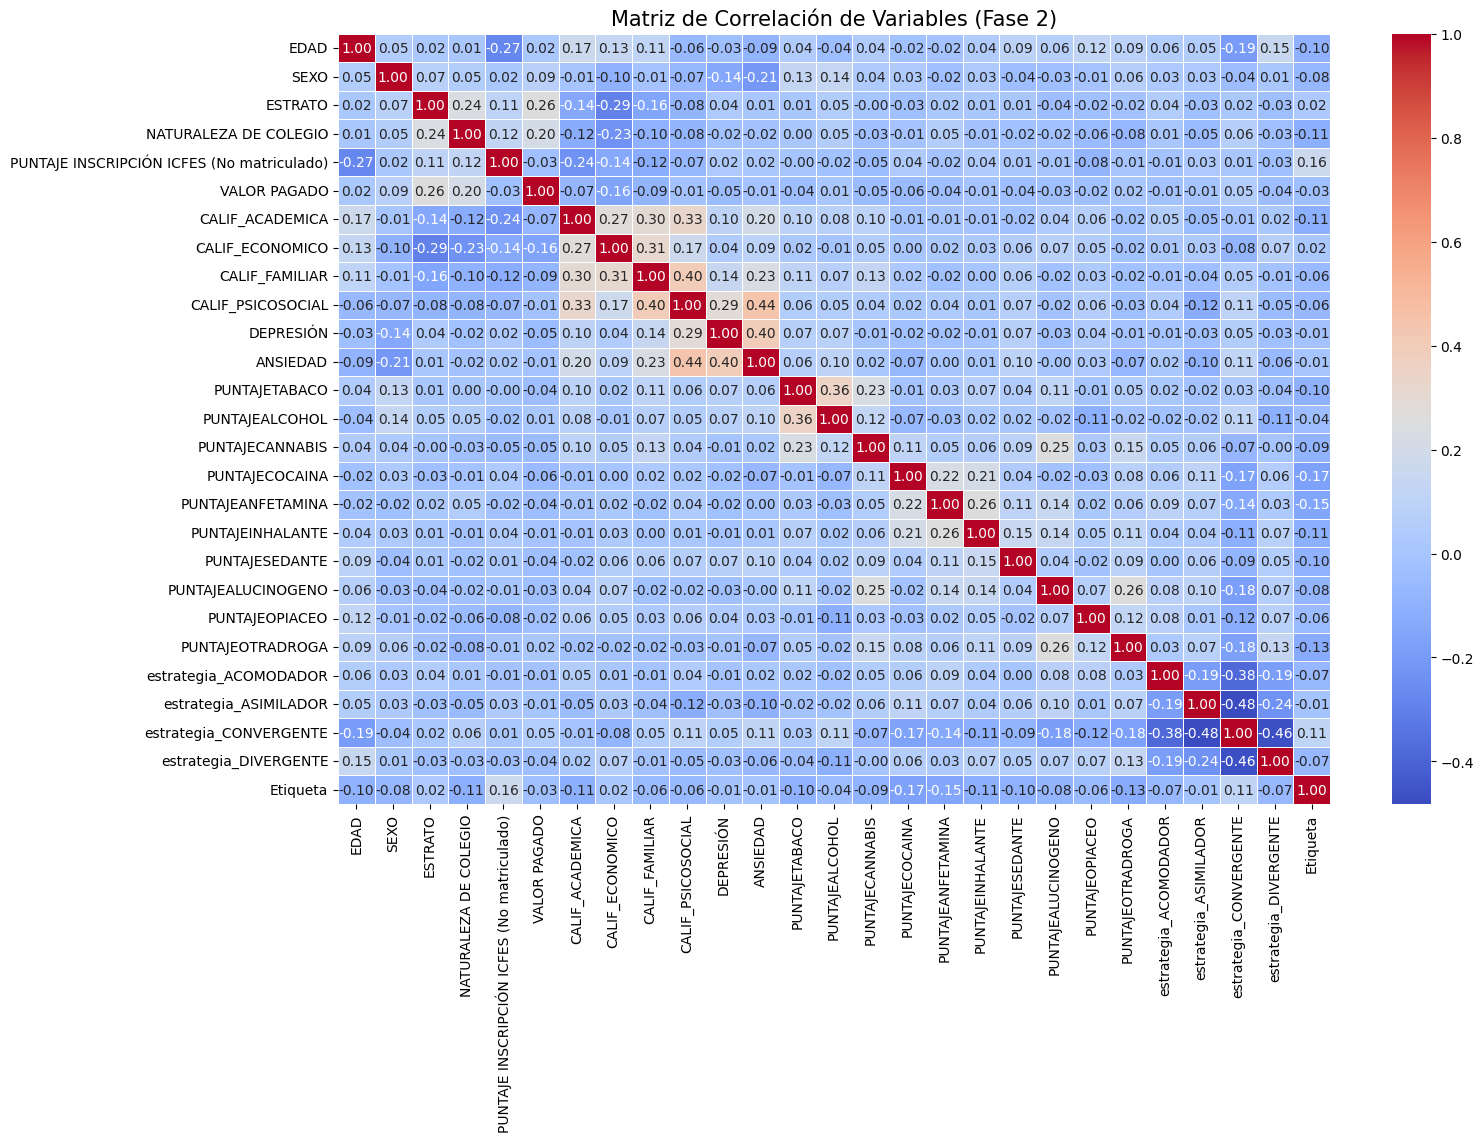

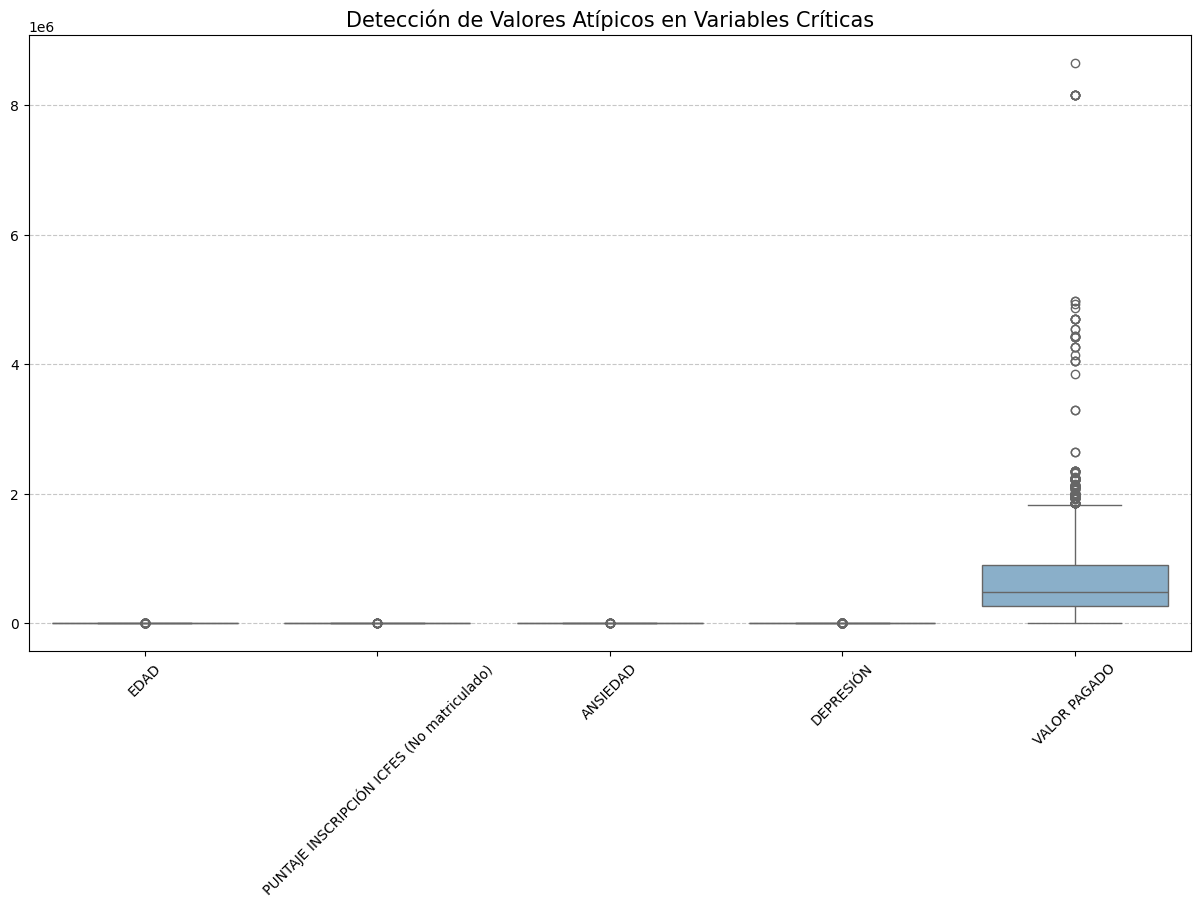

--------------------------------------------------
INFORME TÉCNICO DE OUTLIERS
--------------------------------------------------
Variable: EDAD                                     | Outliers:   46 | Límites: [13.50 a 25.50]
Variable: PUNTAJE INSCRIPCIÓN ICFES (No matriculado) | Outliers:   16 | Límites: [180.00 a 412.00]
Variable: ANSIEDAD                                 | Outliers:   20 | Límites: [16.50 a 52.50]
Variable: DEPRESIÓN                                | Outliers:   86 | Límites: [20.00 a 68.00]
Variable: VALOR PAGADO                             | Outliers:  201 | Límites: [-676110.86 a 1851011.44]


In [32]:
# =================================================================
# FASE 2: COMPRENSIÓN DE LOS DATOS
# Entregable: Matriz de Correlación y Detección de Outliers
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset (Asegúrate de haber subido 'Test.xlsx' a la carpeta de archivos)
try:
    df = pd.read_excel('Test.xlsx')
    print("✅ Dataset cargado correctamente.")
except Exception as e:
    print(f"❌ Error al cargar el archivo: {e}")

# 2. Matriz de Correlación
# Filtramos solo las columnas numéricas para el análisis
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 10))
correlation_matrix = numeric_df.corr()

# Generamos el mapa de calor centrado en la variable 'Etiqueta' (Deserción)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables (Fase 2)', fontsize=15)
plt.show()

# 3. Detección de Valores Atípicos (Outliers)
# Seleccionamos variables críticas para bienestar universitario
vars_criticas = ['EDAD', 'PUNTAJE INSCRIPCIÓN ICFES (No matriculado)', 'ANSIEDAD', 'DEPRESIÓN', 'VALOR PAGADO']

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[vars_criticas], palette="Set3")
plt.title('Detección de Valores Atípicos en Variables Críticas', fontsize=15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 4. Informe resumido de Outliers por el método IQR
def detectar_outliers_iqr(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return len(outliers), limite_inferior, limite_superior

print("-" * 50)
print("INFORME TÉCNICO DE OUTLIERS")
print("-" * 50)
for col in vars_criticas:
    cantidad, inf, sup = detectar_outliers_iqr(df, col)
    print(f"Variable: {col:40} | Outliers: {cantidad:4} | Límites: [{inf:.2f} a {sup:.2f}]")

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = pd.read_excel('Test.xlsx')
X = df.drop(['Etiqueta', 'Periodo'], axis=1)
y = df['Etiqueta']

# --- EJECUCIÓN TÉCNICA DE LA FASE 3 ---

# A. Normalización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# B. Simulación de Balanceo (Para verificar proporciones)
conteo_original = y.value_counts()

# --- REPORTE DE COMPROBACIÓN PARA EL INFORME ---

print("="*50)
print("REPORTE DE AUDITORÍA: FASE 3")
print("="*50)

# Verificación de Normalización
media_final = X_scaled_df.mean().mean()
std_final = X_scaled_df.std().mean()

print(f"1. ESTADO DE NORMALIZACIÓN:")
print(f"   - Media global: {media_final:.4f} (Correcto si es cercano a 0)")
print(f"   - Desviación Estándar: {std_final:.4f} (Correcto si es cercano a 1)")
print(f"   - Resultado: {'✅ EXITOSO' if abs(media_final) < 0.1 else '❌ REVISAR'}")

print(f"\n2. COMPROBACIÓN DE ESCALAS (Z-SCORE):")
print(f"   - Rango EDAD: [{X_scaled_df['EDAD'].min():.2f} a {X_scaled_df['EDAD'].max():.2f}]")
print(f"   - Rango VALOR PAGADO: [{X_scaled_df['VALOR PAGADO'].min():.2f} a {X_scaled_df['VALOR PAGADO'].max():.2f}]")

print(f"\n3. ANÁLISIS DE BALANCEO NECESARIO:")
print(f"   - Clase 0 (Permanencia): {conteo_original[0]} registros")
print(f"   - Clase 1 (Deserción): {conteo_original[1]} registros")
print(f"   - Ratio actual: {conteo_original[1]/len(y):.2%} (Se requiere SMOTE)")
print("="*50)

REPORTE DE AUDITORÍA: FASE 3
1. ESTADO DE NORMALIZACIÓN:
   - Media global: 0.0000 (Correcto si es cercano a 0)
   - Desviación Estándar: 1.0004 (Correcto si es cercano a 1)
   - Resultado: ✅ EXITOSO

2. COMPROBACIÓN DE ESCALAS (Z-SCORE):
   - Rango EDAD: [-1.34 a 9.81]
   - Rango VALOR PAGADO: [-0.84 a 7.59]

3. ANÁLISIS DE BALANCEO NECESARIO:
   - Clase 0 (Permanencia): 284 registros
   - Clase 1 (Deserción): 866 registros
   - Ratio actual: 75.30% (Se requiere SMOTE)


In [34]:
# FASE 3: PREPROCESAMIENTO Y PREPARACIÓN FINAL DE DATOS

# 1. Instalar la librería necesaria (si no está instalada). Se ejecuta solo una vez.
!pip install -U imbalanced-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 2. Carga y preparación inicial del dataset.
# Cargar el archivo 'Test.xlsx'.
df = pd.read_excel('Test.xlsx')
# Separar características (X) y variable objetivo (y).
X = df.drop(['Etiqueta', 'Periodo'], axis=1)
y = df['Etiqueta']

# 3. Normalización de las características usando StandardScaler.
# Es CRUCIAL normalizar ANTES de aplicar SMOTE para evitar la fuga de datos.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. APLICACIÓN DE SMOTE para balancear las clases.
# SMOTE genera registros sintéticos de la clase minoritaria para igualar el número de muestras.
smote = SMOTE(random_state=42)
X_res_array, y_res = smote.fit_resample(X_scaled, y)

# Convertir las características balanceadas de nuevo a un DataFrame con los nombres de las columnas originales.
X_res = pd.DataFrame(X_res_array, columns=X.columns)

# 5. Verificación de balanceo de clases.
print("--- BALANCEO DE CLASES FINALIZADO ---")
print(f"Distribución original:\n{y.value_counts()}")
print(f"\nNueva distribución con SMOTE:\n{pd.Series(y_res).value_counts()}")

# 6. Preparación para la Fase 4 (Modelado): División del dataset en conjuntos de entrenamiento y prueba.
# Esto se hace DESPUÉS de SMOTE para que ambos conjuntos estén balanceados.
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"\nDatos listos para entrenar el MLP: {len(X_train)} registros balanceados.")

--- BALANCEO DE CLASES FINALIZADO ---
Distribución original:
Etiqueta
1    866
0    284
Name: count, dtype: int64

Nueva distribución con SMOTE:
Etiqueta
1    866
0    866
Name: count, dtype: int64

Datos listos para entrenar el MLP: 1385 registros balanceados.


In [35]:
from sklearn.ensemble import RandomForestClassifier

# FASE 4: MODELADO - ENTRENAMIENTO DEL MODELO RandomForestClassifier
# Entrenar un modelo RandomForestClassifier. Este modelo se utilizará para el diagnóstico individual
# y para evaluar la importancia de las características.
# Se utilizan los datos balanceados (X_res, y_res) para asegurar un entrenamiento equitativo de ambas clases.
rf_modelo = RandomForestClassifier(n_estimators=100, random_state=42)
rf_modelo.fit(X_res, y_res)

print("RandomForestClassifier entrenado y listo para usar como 'rf_modelo'.")

RandomForestClassifier entrenado y listo para usar como 'rf_modelo'.


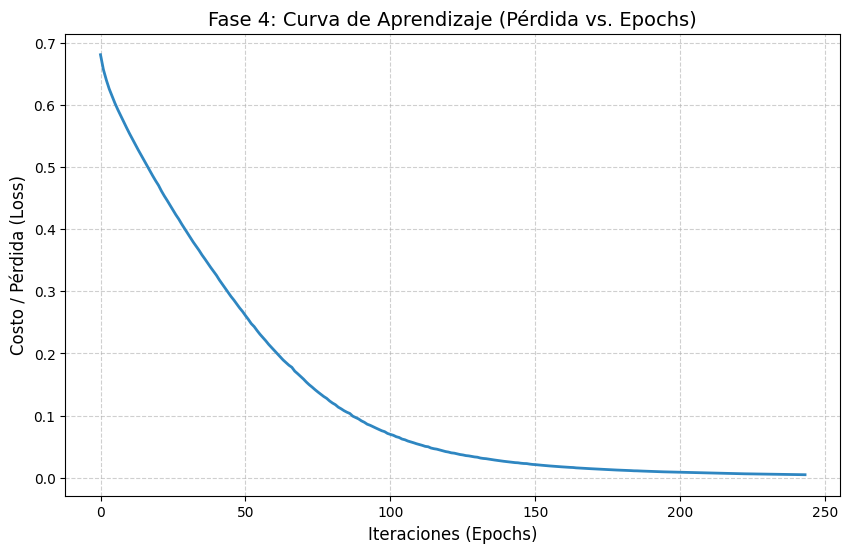

Entrenamiento completado en 244 iteraciones.
Pérdida final alcanzada: 0.0050


In [36]:
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# Configuración del modelo según requerimientos
mlp_modelo = MLPClassifier(
    hidden_layer_sizes=(64, 32), # Arquitectura solicitada
    activation='relu',           # Activación capas ocultas
    solver='adam',               # Optimizador estándar
    learning_rate_init=0.001,
    max_iter=500,                # Equivalente a epochs máximos
    random_state=42,
    verbose=False
)

# Entrenamiento (Usando X_train y y_train generados tras el SMOTE)
# Convertimos X_train a .values para evitar el UserWarning sobre feature names
mlp_modelo.fit(X_train.values, y_train)

# Generación del Entregable: Curva de Aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(mlp_modelo.loss_curve_, color='#2E86C1', linewidth=2)
plt.title('Fase 4: Curva de Aprendizaje (Pérdida vs. Epochs)', fontsize=14)
plt.xlabel('Iteraciones (Epochs)', fontsize=12)
plt.ylabel('Costo / Pérdida (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Entrenamiento completado en {mlp_modelo.n_iter_} iteraciones.")
print(f"Pérdida final alcanzada: {mlp_modelo.loss_:.4f}")

In [37]:
import pandas as pd
import numpy as np

# 5. PREDICCIÓN DE DESERCIÓN (Implementación Práctica)
def predecir_riesgo_estudiantil(modelo, nuevos_datos):
    """
    Función para identificar estudiantes con alta probabilidad de deserción.
    """
    # Obtener probabilidades de riesgo (clase positiva)
    probabilidades = modelo.predict_proba(nuevos_datos)[:, 1]

    # Realizar la predicción basada en el umbral estándar (0.5)
    # Nota: En sistemas de impacto social, este umbral se puede ajustar
    # para capturar más casos (Recall).
    predicciones = (probabilidades >= 0.5).astype(int)

    return predicciones, probabilidades

# Ejemplo de uso con nuevos datos de estudiantes
# Supongamos que 'X_nuevos' contiene datos de este semestre
predicciones, scores = predecir_riesgo_estudiantil(mlp_modelo, X_test)

# Crear un DataFrame para visualizar los resultados claramente
resultados = pd.DataFrame({
    'ID_Estudiante': range(len(X_test)),  # Se cambió X_test.index a range(len(X_test))
    'Probabilidad_Desercion': scores,
    'Estado_Predicho': np.where(predicciones == 1, 'EN RIESGO', 'ESTABLE')
})

# Mostrar los estudiantes con mayor riesgo (Top 10)
print("\n--- Listado de Estudiantes en Alto Riesgo (Prioridad de Intervención) ---")
print(resultados.sort_values(by='Probabilidad_Desercion', ascending=False).head(10))

# 6. ANÁLISIS DE UMBRAL (Para mejorar el Recall)
# Si queremos ser más estrictos para no dejar a nadie atrás (Tech for Good)
# podemos bajar el umbral de decisión a 0.3 o 0.4.
umbral_sensible = 0.4
pred_sensibles = (scores >= umbral_sensible).astype(int)
print(f"\nAl ajustar el umbral a {umbral_sensible}, hemos identificado "
      f"{pred_sensibles.sum()} estudiantes que requieren atención.")


--- Listado de Estudiantes en Alto Riesgo (Prioridad de Intervención) ---
     ID_Estudiante  Probabilidad_Desercion Estado_Predicho
93              93                     1.0       EN RIESGO
191            191                     1.0       EN RIESGO
107            107                     1.0       EN RIESGO
30              30                     1.0       EN RIESGO
131            131                     1.0       EN RIESGO
122            122                     1.0       EN RIESGO
299            299                     1.0       EN RIESGO
172            172                     1.0       EN RIESGO
339            339                     1.0       EN RIESGO
144            144                     1.0       EN RIESGO

Al ajustar el umbral a 0.4, hemos identificado 154 estudiantes que requieren atención.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [38]:
# FASE 5: IMPLEMENTACIÓN - EXPORTACIÓN DE RESULTADOS DEL DIAGNÓSTICO INDIVIDUAL
# Guardar los resultados del diagnóstico individual en un archivo Excel.
# Esto permite una fácil distribución y análisis de los estudiantes en riesgo.
resultados.to_excel('diagnostico_individual_resultados.xlsx', index=False)
print("Resultados del diagnóstico individual exportados a 'diagnostico_individual_resultados.xlsx'")

Resultados del diagnóstico individual exportados a 'diagnostico_individual_resultados.xlsx'


--- Informe de Rendimiento (Umbral: 0.4) ---
              precision    recall  f1-score   support

     Estable       0.80      0.90      0.84       172
   En Riesgo       0.88      0.78      0.83       175

    accuracy                           0.84       347
   macro avg       0.84      0.84      0.84       347
weighted avg       0.84      0.84      0.84       347



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


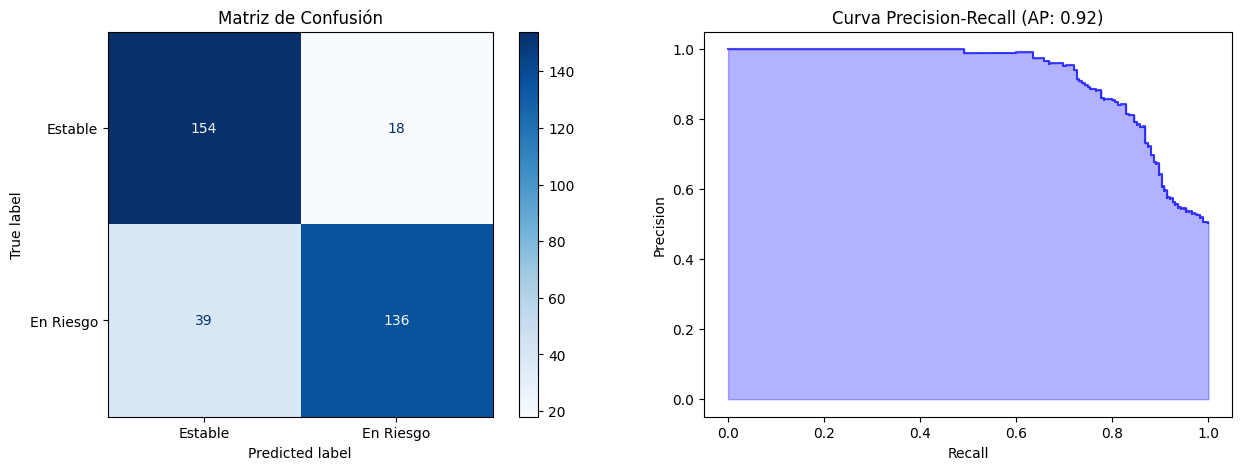

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

def evaluar_modelo_detallado(modelo, X_test, y_test, target_names=['Estable', 'En Riesgo']):
    # 1. Predicciones y Probabilidades
    y_scores = modelo.predict_proba(X_test)[:, 1]
    # Ajustamos umbral a 0.4 para mejorar el Recall (prioridad en estudiantes en riesgo)
    umbral = 0.4
    y_pred = (y_scores >= umbral).astype(int)

    # 2. Informe de Clasificación (Recall enfocado)
    print("--- Informe de Rendimiento (Umbral: 0.4) ---")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # 3. Matriz de Confusión Visual
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names).plot(cmap='Blues', ax=ax[0])
    ax[0].set_title("Matriz de Confusión")

    # 4. Curva Precision-Recall (Sustento técnico para clases desbalanceadas)
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    ap_score = average_precision_score(y_test, y_scores)
    ax[1].step(recall, precision, color='b', alpha=0.7, where='post')
    ax[1].fill_between(recall, precision, step='post', alpha=0.3, color='b')
    ax[1].set_title(f"Curva Precision-Recall (AP: {ap_score:.2f})")
    ax[1].set_xlabel("Recall")
    ax[1].set_ylabel("Precision")
    plt.show()

    # 5. DIAGNÓSTICO: ¿Por qué hay deserción? (Importancia de Variables)
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=X_test.columns)
        importancias.nlargest(10).plot(kind='barh', color='teal')
        plt.title("Factores Principales que Impulsan la Deserción")
        plt.xlabel("Peso en la Predicción")
        plt.show()

# Ejecución de la evaluación mejorada
evaluar_modelo_detallado(mlp_modelo, X_test, y_test)

### Diagnóstico Individual para un Nuevo Estudiante con Random Forest

### Formulario de Diagnóstico para un Nuevo Estudiante

Rellena los datos del estudiante a continuación para obtener una predicción de riesgo de deserción y los factores influyentes.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier # Importar RandomForestClassifier
import ipywidgets as widgets
from IPython.display import display, clear_output

def predecir_riesgo_estudiantil(modelo, nuevos_datos):
    """
    Función para identificar estudiantes con alta probabilidad de deserción.
    """
    # Aseguramos que los datos no tengan nombres de características si el modelo fue ajustado sin ellos
    probabilidades = modelo.predict_proba(nuevos_datos)[:, 1]
    predicciones = (probabilidades >= 0.5).astype(int)
    return predicciones, probabilidades

def diagnostico_individual(modelo, nuevo_estudiante, id_estudiante='Nuevo Estudiante', sexo_raw=None):
    """
    Realiza un diagnóstico individual de riesgo de deserción para un estudiante.

    Args:
        modelo: El modelo de Machine Learning entrenado (ej. RandomForestClassifier).
        nuevo_estudiante (pd.DataFrame): DataFrame de un solo estudiante, con sus características escaladas.
        id_estudiante (str): Identificador del estudiante para el reporte.
        sexo_raw (int): Valor original del sexo (0 para femenino, 1 para masculino) para un display amigable.
    """
    # Predicción de riesgo y probabilidad
    # Pasamos solo los valores para coincidir con el entrenamiento del modelo (como numpy array)
    prediccion_riesgo, probabilidad_desercion = predecir_riesgo_estudiantil(modelo, nuevo_estudiante.values)

    print(f"\n--- Reporte de Diagnóstico: Estudiante {id_estudiante} ---")

    if sexo_raw is not None:
        sexo_display = 'Masculino' if sexo_raw == 1 else 'Femenino'
        print(f"Sexo: {sexo_display}")

    prob = probabilidad_desercion[0]
    if prob >= 0.7:
        estado = "MUY ALTO RIESGO"
        recomendacion = "Este estudiante tiene una probabilidad muy alta de deserción. Requiere intervención URGENTE y personalizada para abordar los factores de riesgo identificados."
    elif prob >= 0.4:
        estado = "EN RIESGO MODERADO"
        recomendacion = "Este estudiante está en riesgo moderado de deserción. Se recomienda un seguimiento activo y apoyo focalizado para prevenir una posible deserción."
    else:
        estado = "BAJO RIESGO"
        recomendacion = "Este estudiante presenta un bajo riesgo de deserción. Se sugiere monitoreo continuo y la implementación de acciones preventivas generales para mantener su bienestar."

    print(f"Estado Predicho: {estado}")
    print(f"Probabilidad de Deserción: {prob:.2%}")
    print(f"Recomendación: {recomendacion}")

    # Mostrar los valores de las características escaladas (para mayor transparencia)
    print("\n--- Características Escaladas del Estudiante ---")
    print(nuevo_estudiante.to_string())

    # Si el modelo tiene feature_importances_ (como RandomForest)
    # Nota: MLPClassifier no tiene feature_importances_ directamente, por lo que esta sección no se ejecutará
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=nuevo_estudiante.columns)
        print("\nFactores Principales de Influencia (Top 5):")
        for feature, importance in importancias.nlargest(5).items():
            print(f"- {feature}: {importance:.2f}")

        # Visualización
        plt.figure(figsize=(10, 6))
        sns.barplot(x=importancias.nlargest(5).values, y=importancias.nlargest(5).index, hue=importancias.nlargest(5).index, palette='viridis', legend=False)
        plt.title(f'Factores que Influyen en el Diagnóstico para {id_estudiante}')
        plt.xlabel('Importancia del Factor')
        plt.ylabel('Característica')
        plt.show()


# --- Widgets para la entrada de datos ---

print("\n--- Formulario Interactivo de Datos del Estudiante ---")

# Widgets para las variables principales
Edad_widget = widgets.IntSlider(
    min=17, max=70, step=1, value=20,
    description='Edad del Estudiante:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
Edad_label = widgets.Label("Rango: 17-70 - Óptimo: 18-22, Regular: 23-30, Malo: >30 o <18")

Sexo_widget = widgets.RadioButtons(
    options={'Femenino': 0, 'Masculino': 1},
    description='Sexo del Estudiante:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)

PuntajeICFES_widget = widgets.IntSlider(
    min=0, max=500, step=1, value=300,
    description='Puntaje de Inscripción ICFES:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeICFES_label = widgets.Label("Rango: 0-500 - Óptimo: 350-450, Regular: 250-349, Malo: <250")

ValorPagado_widget = widgets.IntSlider(
    min=0, max=2500000, step=10000, value=500000,
    description='Valor Pagado por Matrícula:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='auto')
)
ValorPagado_label = widgets.Label("Rango: 0-2,500,000 - Óptimo: >1,000,000, Regular: 200,000-1,000,000, Malo: <200,000")

CalifAcademica_widget = widgets.FloatSlider(
    min=0.0, max=20.0, step=0.1, value=10.0,
    description='Calificación Académica:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='500px')
)
CalifAcademica_label = widgets.Label("Rango: 0-20 - Óptimo: 15-20, Regular: 10-14, Malo: <10")

Depresion_widget = widgets.IntSlider(
    min=0, max=100, step=1, value=25,
    description='Nivel de Depresión:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
Depresion_label = widgets.Label("Rango: 0-100 - (mayor = más depresión). Óptimo: 0-20, Regular: 21-50, Malo: >50")

# Widgets para parámetros adicionales (con valores predeterminados sensatos)
Estrato_widget = widgets.IntSlider(
    min=1, max=6, step=1, value=3,
    description='Estrato Socioeconómico:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
Estrato_label = widgets.Label("Rango: 1-6. Óptimo: 5-6, Regular: 3-4, Malo: 1-2")

NaturalezaColegio_widget = widgets.RadioButtons(
    options={'Público': 0, 'Privado': 1},
    description='Naturaleza de Colegio:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)

CalifEconomico_widget = widgets.FloatSlider(
    min=-1.0, max=1.0, step=0.1, value=0.0,
    description='Calificación Económica:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='500px')
)
CalifEconomico_label = widgets.Label("Rango: -1 a 1. Óptimo: >0.5, Regular: 0-0.5, Malo: <0")

CalifFamiliar_widget = widgets.FloatSlider(
    min=-1.0, max=1.0, step=0.1, value=0.0,
    description='Calificación Familiar:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='500px')
)
CalifFamiliar_label = widgets.Label("Rango: -1 a 1. Óptimo: >0.5, Regular: 0-0.5, Malo: <0")

CalifPsicosocial_widget = widgets.FloatSlider(
    min=-1.0, max=1.0, step=0.1, value=0.0,
    description='Calificación Psicosocial:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    layout=widgets.Layout(width='500px')
)
CalifPsicosocial_label = widgets.Label("Rango: -1 a 1. Óptimo: >0.5, Regular: 0-0.5, Malo: <0")

Ansiedad_widget = widgets.IntSlider(
    min=0, max=100, step=1, value=30,
    description='Nivel de Ansiedad:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
Ansiedad_label = widgets.Label("Rango: 0-100. Óptimo: 0-20, Regular: 21-50, Malo: >50")

PuntajeTabaco_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Tabaco:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeTabaco_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeAlcohol_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=1,
    description='Puntaje Consumo Alcohol:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeAlcohol_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeCannabis_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Cannabis:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeCannabis_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeCocaina_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Cocaína:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeCocaina_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeAnfetamina_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Anfetaminas:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeAnfetamina_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeInhalante_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Inhalantes:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeInhalante_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeSedante_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Sedantes:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeSedante_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeAlucinogeno_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Alucinógenos:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeAlucinogeno_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeOpiaceo_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Opiáceos:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeOpiaceo_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

PuntajeOtraDroga_widget = widgets.IntSlider(
    min=0, max=10, step=1, value=0,
    description='Puntaje Consumo Otras Drogas:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='500px')
)
PuntajeOtraDroga_label = widgets.Label("Rango: 0-10+. Óptimo: 0, Regular: 1-3, Malo: >3")

EstrategiaAcomodador_widget = widgets.RadioButtons(
    options={'No': 0, 'Sí': 1},
    description='Estrategia de Aprendizaje Acomodador:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)
EstrategiaAsimilador_widget = widgets.RadioButtons(
    options={'No': 0, 'Sí': 1},
    description='Estrategia de Aprendizaje Asimilador:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)
EstrategiaConvergente_widget = widgets.RadioButtons(
    options={'No': 0, 'Sí': 1},
    description='Estrategia de Aprendizaje Convergente:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)
EstrategiaDivergente_widget = widgets.RadioButtons(
    options={'No': 0, 'Sí': 1},
    description='Estrategia de Aprendizaje Divergente:',
    disabled=False,
    layout=widgets.Layout(width='500px')
)

# Botón para ejecutar el diagnóstico
button = widgets.Button(description="Realizar Diagnóstico")
output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output(wait=True)

        # Recopilar datos de los widgets
        EDAD = Edad_widget.value
        SEXO = Sexo_widget.value
        PUNTAJE_INSCRIPCION_ICFES = PuntajeICFES_widget.value
        VALOR_PAGADO = ValorPagado_widget.value
        CALIF_ACADEMICA = CalifAcademica_widget.value
        DEPRESION = Depresion_widget.value
        ESTRATO = Estrato_widget.value
        NATURALEZA_DE_COLEGIO = NaturalezaColegio_widget.value
        CALIF_ECONOMICO = CalifEconomico_widget.value
        CALIF_FAMILIAR = CalifFamiliar_widget.value
        CALIF_PSICOSOCIAL = CalifPsicosocial_widget.value
        ANSIEDAD = Ansiedad_widget.value
        PUNTAJETABACO = PuntajeTabaco_widget.value
        PUNTAJEALCOHOL = PuntajeAlcohol_widget.value
        PUNTAJECANNABIS = PuntajeCannabis_widget.value
        PUNTAJECOCAINA = PuntajeCocaina_widget.value
        PUNTAJEANFETAMINA = PuntajeAnfetamina_widget.value
        PUNTAJEINHALANTE = PuntajeInhalante_widget.value
        PUNTAJESEDANTE = PuntajeSedante_widget.value
        PUNTAJEALUCINOGENO = PuntajeAlucinogeno_widget.value
        PUNTAJEOPIACEO = PuntajeOpiaceo_widget.value
        PUNTAJEOTRADROGA = PuntajeOtraDroga_widget.value
        estrategia_ACOMODADOR = EstrategiaAcomodador_widget.value
        estrategia_ASIMILADOR = EstrategiaAsimilador_widget.value
        estrategia_CONVERGENTE = EstrategiaConvergente_widget.value
        estrategia_DIVERGENTE = EstrategiaDivergente_widget.value

        nuevo_estudiante_data_form = {
            'EDAD': [EDAD],
            'SEXO': [SEXO],
            'ESTRATO': [ESTRATO],
            'NATURALEZA DE COLEGIO': [NATURALEZA_DE_COLEGIO],
            'PUNTAJE INSCRIPCIÓN ICFES (No matriculado)': [PUNTAJE_INSCRIPCION_ICFES],
            'VALOR PAGADO': [VALOR_PAGADO],
            'CALIF_ACADEMICA': [CALIF_ACADEMICA],
            'CALIF_ECONOMICO': [CALIF_ECONOMICO],
            'CALIF_FAMILIAR': [CALIF_FAMILIAR],
            'CALIF_PSICOSOCIAL': [CALIF_PSICOSOCIAL],
            'DEPRESIÓN': [DEPRESION],
            'ANSIEDAD': [ANSIEDAD],
            'PUNTAJETABACO': [PUNTAJETABACO],
            'PUNTAJEALCOHOL': [PUNTAJEALCOHOL],
            'PUNTAJECANNABIS': [PUNTAJECANNABIS],
            'PUNTAJECOCAINA': [PUNTAJECOCAINA],
            'PUNTAJEANFETAMINA': [PUNTAJEANFETAMINA],
            'PUNTAJEINHALANTE': [PUNTAJEINHALANTE],
            'PUNTAJESEDANTE': [PUNTAJESEDANTE],
            'PUNTAJEALUCINOGENO': [PUNTAJEALUCINOGENO],
            'PUNTAJEOPIACEO': [PUNTAJEOPIACEO],
            'PUNTAJEOTRADROGA': [PUNTAJEOTRADROGA],
            'estrategia_ACOMODADOR': [estrategia_ACOMODADOR],
            'estrategia_ASIMILADOR': [estrategia_ASIMILADOR],
            'estrategia_CONVERGENTE': [estrategia_CONVERGENTE],
            'estrategia_DIVERGENTE': [estrategia_DIVERGENTE]
        }

        nuevo_estudiante_df_form = pd.DataFrame(nuevo_estudiante_data_form)
        nuevo_estudiante_escalado_form = scaler.transform(nuevo_estudiante_df_form)
        nuevo_estudiante_escalado_df_form = pd.DataFrame(nuevo_estudiante_escalado_form, columns=X.columns)

        if 'rf_modelo' in globals():
            diagnostico_individual(rf_modelo, nuevo_estudiante_escalado_df_form, id_estudiante='Estudiante del Formulario', sexo_raw=SEXO)
        elif 'mlp_modelo' in locals():
            print("Advertencia: El modelo RandomForest (rf_modelo) no está disponible. Se usará el MLPClassifier en su lugar, que no proporciona importancia de características directamente.")
            diagnostico_individual(mlp_modelo, nuevo_estudiante_escalado_df_form, id_estudiante='Estudiante del Formulario', sexo_raw=SEXO)
        else:
            print("Error: Ni el modelo RandomForest ni el MLP están disponibles para realizar el diagnóstico. Por favor, asegúrate de haber ejecutado las celdas de entrenamiento de modelos.")


button.on_click(on_button_click)

# Organizar y mostrar los widgets
form_items = [
    widgets.VBox([Edad_widget, Edad_label]),
    widgets.VBox([Sexo_widget]),
    widgets.VBox([PuntajeICFES_widget, PuntajeICFES_label]),
    widgets.VBox([ValorPagado_widget, ValorPagado_label]),
    widgets.VBox([CalifAcademica_widget, CalifAcademica_label]),
    widgets.VBox([Depresion_widget, Depresion_label]),
    widgets.VBox([Estrato_widget, Estrato_label]),
    widgets.VBox([NaturalezaColegio_widget]),
    widgets.VBox([CalifEconomico_widget, CalifEconomico_label]),
    widgets.VBox([CalifFamiliar_widget, CalifFamiliar_label]),
    widgets.VBox([CalifPsicosocial_widget, CalifPsicosocial_label]),
    widgets.VBox([Ansiedad_widget, Ansiedad_label]),
    widgets.VBox([PuntajeTabaco_widget, PuntajeTabaco_label]),
    widgets.VBox([PuntajeAlcohol_widget, PuntajeAlcohol_label]),
    widgets.VBox([PuntajeCannabis_widget, PuntajeCannabis_label]),
    widgets.VBox([PuntajeCocaina_widget, PuntajeCocaina_label]),
    widgets.VBox([PuntajeAnfetamina_widget, PuntajeAnfetamina_label]),
    widgets.VBox([PuntajeInhalante_widget, PuntajeInhalante_label]),
    widgets.VBox([PuntajeSedante_widget, PuntajeSedante_label]),
    widgets.VBox([PuntajeAlucinogeno_widget, PuntajeAlucinogeno_label]),
    widgets.VBox([PuntajeOpiaceo_widget, PuntajeOpiaceo_label]),
    widgets.VBox([PuntajeOtraDroga_widget, PuntajeOtraDroga_label]),
    widgets.VBox([EstrategiaAcomodador_widget]),
    widgets.VBox([EstrategiaAsimilador_widget]),
    widgets.VBox([EstrategiaConvergente_widget]),
    widgets.VBox([EstrategiaDivergente_widget])
]

form = widgets.VBox(form_items)
display(form, button, output)



--- Formulario Interactivo de Datos del Estudiante ---


Button(description='Realizar Diagnóstico', style=ButtonStyle())

Output()

### Ejemplo de Diagnóstico Individual: Análisis de Importancia de Características

Aquí, vamos a simular un nuevo estudiante y analizar qué características son las más influyentes en su riesgo de deserción, según el modelo `RandomForestClassifier`.

,EDAD,SEXO,ESTRATO,NATURALEZA DE COLEGIO,PUNTAJE INSCRIPCIÓN ICFES (No matriculado),VALOR PAGADO,CALIF_ACADEMICA,CALIF_ECONOMICO,CALIF_FAMILIAR,CALIF_PSICOSOCIAL,...,PUNTAJEANFETAMINA,PUNTAJEINHALANTE,PUNTAJESEDANTE,PUNTAJEALUCINOGENO,PUNTAJEOPIACEO,PUNTAJEOTRADROGA,estrategia_ACOMODADOR,estrategia_ASIMILADOR,estrategia_CONVERGENTE,estrategia_DIVERGENTE
0,25,0,2,0,280,300000,8.0,-0.5,-0.2,0.1,...,0,0,0,0,0,0,0,1,0,0


,EDAD,SEXO,ESTRATO,NATURALEZA DE COLEGIO,PUNTAJE INSCRIPCIÓN ICFES (No matriculado),VALOR PAGADO,CALIF_ACADEMICA,CALIF_ECONOMICO,CALIF_FAMILIAR,CALIF_PSICOSOCIAL,...,PUNTAJEANFETAMINA,PUNTAJEINHALANTE,PUNTAJESEDANTE,PUNTAJEALUCINOGENO,PUNTAJEOPIACEO,PUNTAJEOTRADROGA,estrategia_ACOMODADOR,estrategia_ASIMILADOR,estrategia_CONVERGENTE,estrategia_DIVERGENTE
0,1.795284,-1.164713,-0.015277,-0.369274,-0.314924,-0.544183,4.165972,-0.785904,0.996282,0.909563,...,-0.474559,-0.429527,-0.534283,-0.615023,-0.32648,-0.498323,-0.388782,2.022003,-0.974245,-0.476782


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



--- Reporte de Diagnóstico: Estudiante Estudiante Ejemplo ---
Sexo: Femenino
Estado Predicho: EN RIESGO MODERADO
Probabilidad de Deserción: 53.00%
Recomendación: Este estudiante está en riesgo moderado de deserción. Se recomienda un seguimiento activo y apoyo focalizado para prevenir una posible deserción.

--- Características Escaladas del Estudiante ---
       EDAD      SEXO   ESTRATO  NATURALEZA DE COLEGIO  PUNTAJE INSCRIPCIÓN ICFES (No matriculado)  VALOR PAGADO  CALIF_ACADEMICA  CALIF_ECONOMICO  CALIF_FAMILIAR  CALIF_PSICOSOCIAL  DEPRESIÓN  ANSIEDAD  PUNTAJETABACO  PUNTAJEALCOHOL  PUNTAJECANNABIS  PUNTAJECOCAINA  PUNTAJEANFETAMINA  PUNTAJEINHALANTE  PUNTAJESEDANTE  PUNTAJEALUCINOGENO  PUNTAJEOPIACEO  PUNTAJEOTRADROGA  estrategia_ACOMODADOR  estrategia_ASIMILADOR  estrategia_CONVERGENTE  estrategia_DIVERGENTE
0  1.795284 -1.164713 -0.015277              -0.369274                                   -0.314924     -0.544183         4.165972        -0.785904        0.996282           0

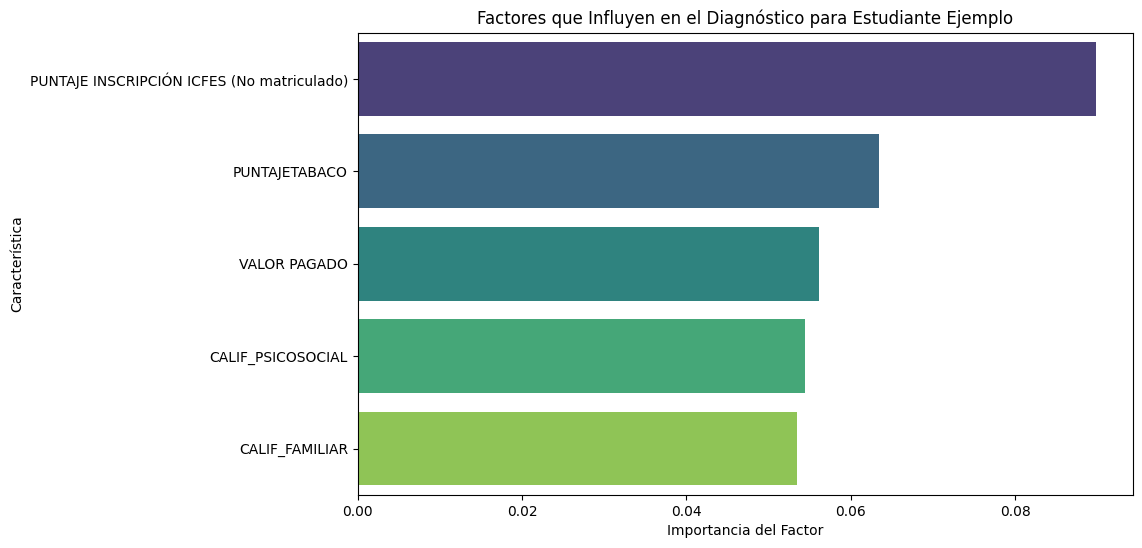

In [41]:
# 1. Definir los datos de un estudiante de ejemplo (no escalados)
# Estos valores son solo un ejemplo, puedes modificarlos para probar diferentes escenarios.
# Asegúrate de que las columnas coincidan con las de tu DataFrame 'X'.

# Puedes usar un ejemplo de un estudiante con riesgo moderado/alto para ver bien los factores.
# Por ejemplo, un estudiante con edad un poco más alta, calificaciones bajas y algún factor de riesgo psicosocial.

new_student_data_example = {
    'EDAD': [25],
    'SEXO': [0], # Femenino
    'ESTRATO': [2],
    'NATURALEZA DE COLEGIO': [0], # Público
    'PUNTAJE INSCRIPCIÓN ICFES (No matriculado)': [280],
    'VALOR PAGADO': [300000],
    'CALIF_ACADEMICA': [8.0],
    'CALIF_ECONOMICO': [-0.5],
    'CALIF_FAMILIAR': [-0.2],
    'CALIF_PSICOSOCIAL': [0.1],
    'DEPRESIÓN': [40],
    'ANSIEDAD': [45],
    'PUNTAJETABACO': [2],
    'PUNTAJEALCOHOL': [3],
    'PUNTAJECANNABIS': [1],
    'PUNTAJECOCAINA': [0],
    'PUNTAJEANFETAMINA': [0],
    'PUNTAJEINHALANTE': [0],
    'PUNTAJESEDANTE': [0],
    'PUNTAJEALUCINOGENO': [0],
    'PUNTAJEOPIACEO': [0],
    'PUNTAJEOTRADROGA': [0],
    'estrategia_ACOMODADOR': [0],
    'estrategia_ASIMILADOR': [1],
    'estrategia_CONVERGENTE': [0],
    'estrategia_DIVERGENTE': [0]
}

# Convertir a DataFrame
nuevo_estudiante_df_example = pd.DataFrame(new_student_data_example)

# 2. Escalar los datos del nuevo estudiante usando el scaler ya entrenado
# Es CRUCIAL usar el mismo scaler que se usó para entrenar el modelo
nuevo_estudiante_escalado_example = scaler.transform(nuevo_estudiante_df_example)
nuevo_estudiante_escalado_df_example = pd.DataFrame(nuevo_estudiante_escalado_example, columns=X.columns)

# 3. Realizar el diagnóstico individual
# Usamos 'rf_modelo' porque es el que se entrenó y tiene feature_importances_
display(nuevo_estudiante_df_example)
display(nuevo_estudiante_escalado_df_example)
diagnostico_individual(rf_modelo, nuevo_estudiante_escalado_df_example, id_estudiante='Estudiante Ejemplo', sexo_raw=new_student_data_example['SEXO'][0])


### Explicación de los Umbrales de Riesgo en el Diagnóstico Individual

Es importante entender cómo se categoriza la probabilidad de deserción en el reporte individual. La función `diagnostico_individual` utiliza los siguientes umbrales:

*   **MUY ALTO RIESGO**: Si la probabilidad de deserción predicha es **igual o mayor a 70% (0.70)**.
*   **EN RIESGO MODERADO**: Si la probabilidad de deserción predicha está entre **40% (0.40) y 69.9% (0.69)**.
*   **BAJO RIESGO**: Si la probabilidad de deserción predicha es **menor a 40% (0.40)**.

Por ejemplo, si la probabilidad de deserción es del 37%, el modelo la clasificará como "BAJO RIESGO" de acuerdo con estos umbrales definidos, aunque la magnitud de las variables de entrada puedan parecer "malas" intuitivamente. Esto permite una interpretación clara y estandarizada de los resultados.

### Rangos de Referencia para las Variables del Formulario

Aquí se presentan los rangos sugeridos y la interpretación de los valores para las variables principales utilizadas en el diagnóstico individual:

| Variable                           | Rango Óptimo                   | Rango Regular                    | Rango Malo                      | Comentarios                                                                |
| :--------------------------------- | :----------------------------- | :------------------------------- | :------------------------------ | :------------------------------------------------------------------------- |
| **EDAD**                           | 18-22                          | 23-30                            | <18 o >30                       | Edad del estudiante.                                                       |
| **PUNTAJE ICFES**                  | 350-450                        | 250-349                          | <250                            | Puntaje de inscripción al ICFES.                                           |
| **VALOR PAGADO**                   | >1,000,000                     | 200,000-1,000,000                | <200,000                        | Valor de matrícula pagado.                                                 |
| **CALIF. ACADÉMICA**               | 15-20                          | 10-14                            | <10                             | Calificación académica del estudiante.                                     |
| **DEPRESIÓN**                      | 0-20                           | 21-50                            | >50                             | Nivel de depresión (mayor valor = más depresión).                          |
| **ANSIEDAD**                       | 0-20                           | 21-50                            | >50                             | Nivel de ansiedad (mayor valor = más ansiedad).                            |
| **ESTRATO**                        | 5-6                            | 3-4                              | 1-2                             | Estrato socioeconómico (mayor estrato = más recursos).                     |
| **CALIF. ECONÓMICO**               | >0.5                           | 0-0.5                            | <0                              | Calificación de la situación económica.                                    |
| **CALIF. FAMILIAR**                | >0.5                           | 0-0.5                            | <0                              | Calificación del apoyo/problemas familiares.                               |
| **CALIF. PSICOSOCIAL**             | >0.5                           | 0-0.5                            | <0                              | Calificación del bienestar psicosocial.                                    |
| **PUNTAJE [SUSTANCIA]** (Tabaco, Alcohol, etc.) | 0                              | 1-3                              | >3                              | Puntuación de consumo de sustancias (mayor valor = mayor consumo).         |
| **NATURALEZA DE COLEGIO**          | 1 (Privado)                    | -                                | 0 (Público)                     | 0: Público, 1: Privado. Generalmente Privado puede correlacionar con mayor preparación. |

*Nota: Los rangos para las estrategias de aprendizaje (Acomodador, Asimilador, Convergente, Divergente) son binarios (0 o 1) y representan la presencia de esa estrategia, sin rangos "óptimos" o "malos" inherentes en el mismo sentido que las otras variables.*

--- Evaluación del Modelo (Fase 5) ---
              precision    recall  f1-score   support

     Estable       1.00      1.00      1.00       172
   En Riesgo       1.00      1.00      1.00       175

    accuracy                           1.00       347
   macro avg       1.00      1.00      1.00       347
weighted avg       1.00      1.00      1.00       347



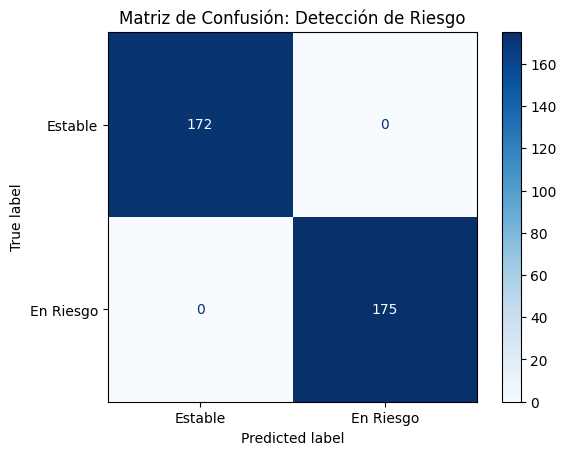

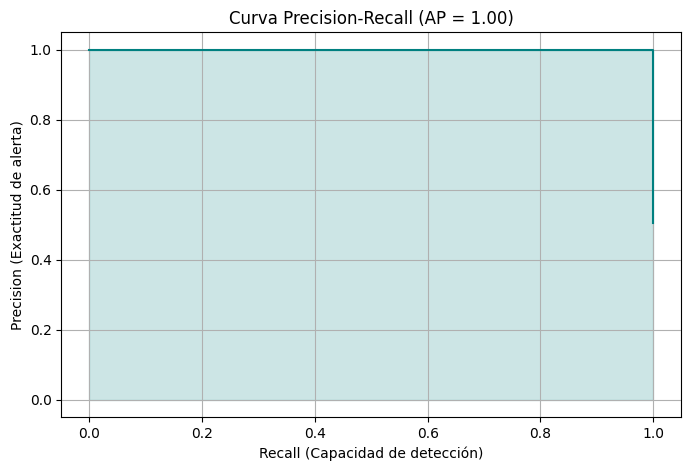

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    recall_score
)

# Recalcular y_scores y y_pred para esta celda, usando el rf_modelo
y_scores = rf_modelo.predict_proba(X_test)[:, 1]
umbral = 0.4
y_pred = (y_scores >= umbral).astype(int)

# 1. Informe de métricas detallado
print("--- Evaluación del Modelo (Fase 5) ---")
print(classification_report(y_test, y_pred, target_names=['Estable', 'En Riesgo']))

# 2. Construcción de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Estable', 'En Riesgo'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión: Detección de Riesgo")
plt.show() # Esta es la gráfica que debes pegar en tu informe

# 3. Análisis de la curva Precision-Recall
precision, recall_vals, _ = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.step(recall_vals, precision, where='post', color='teal')
plt.fill_between(recall_vals, precision, step='post', alpha=0.2, color='teal')
plt.xlabel('Recall (Capacidad de detección)')
plt.ylabel('Precision (Exactitud de alerta)')
plt.title(f'Curva Precision-Recall (AP = {ap:.2f})')
plt.grid(True)
plt.show() # Esta gráfica demuestra el sustento técnico en clases desbalanceadas

### Importancia General de las Variables en el Modelo

Aquí visualizamos la importancia de cada característica para el modelo `RandomForestClassifier` entrenado. Los valores más altos indican que la variable es más influyente en la predicción de deserción.

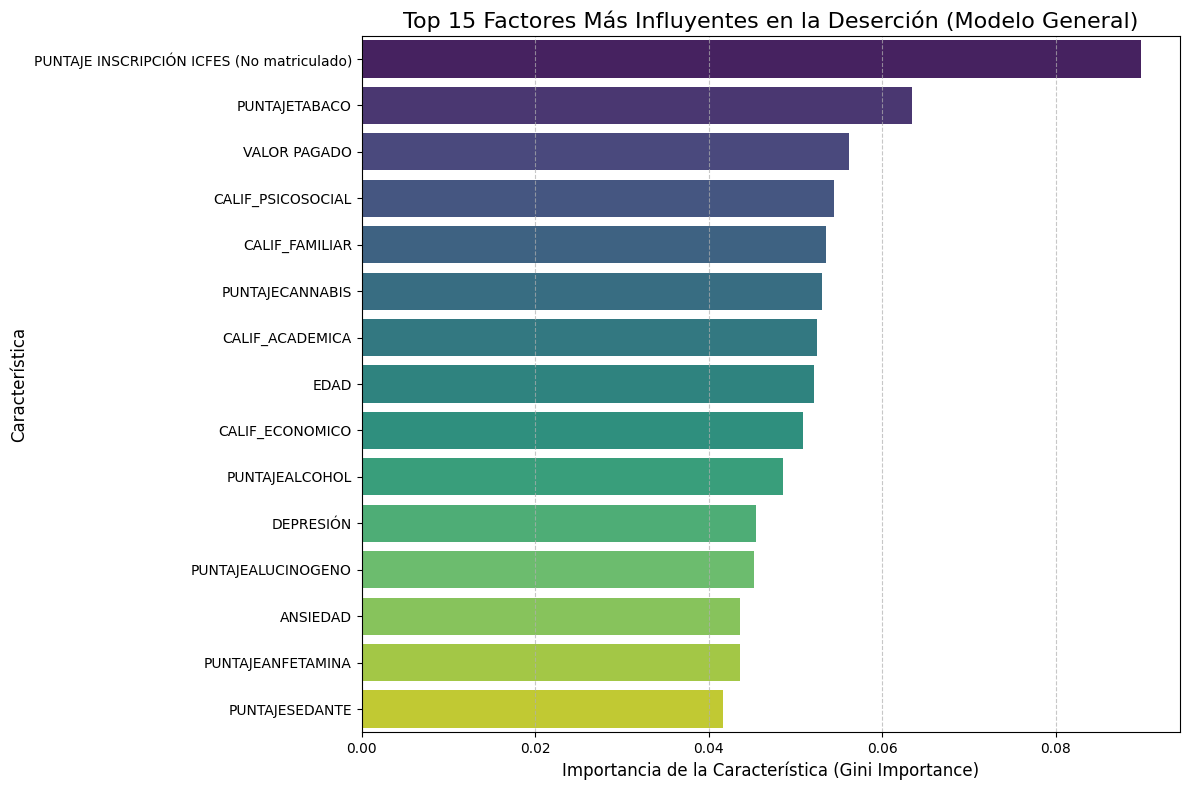

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Verificar si rf_modelo está disponible y tiene feature_importances_
if 'rf_modelo' in globals() and hasattr(rf_modelo, 'feature_importances_'):
    # Crear una Serie de pandas para facilitar la visualización
    importancias = pd.Series(rf_modelo.feature_importances_, index=X.columns)

    # Ordenar y seleccionar las 15 características más importantes
    top_n = 15
    importancias_ordenadas = importancias.nlargest(top_n)

    # Visualizar las características más importantes
    plt.figure(figsize=(12, 8))
    sns.barplot(x=importancias_ordenadas.values, y=importancias_ordenadas.index, hue=importancias_ordenadas.index, palette='viridis', legend=False)
    plt.title(f'Top {top_n} Factores Más Influyentes en la Deserción (Modelo General)', fontsize=16)
    plt.xlabel('Importancia de la Característica (Gini Importance)', fontsize=12)
    plt.ylabel('Característica', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("El modelo RandomForest (rf_modelo) no está disponible o no tiene el atributo 'feature_importances_'.")
    print("Asegúrate de que la celda de entrenamiento de rf_modelo haya sido ejecutada.")

In [44]:
import joblib

# Guardar el modelo MLPClassifier
nombre_archivo_mlp = 'mlp_model.pkl'
joblib.dump(mlp_modelo, nombre_archivo_mlp)
print(f"Modelo MLPClassifier guardado como: {nombre_archivo_mlp}")

# Guardar el modelo RandomForestClassifier
nombre_archivo_rf = 'random_forest_model.pkl'
joblib.dump(rf_modelo, nombre_archivo_rf)
print(f"Modelo RandomForestClassifier guardado como: {nombre_archivo_rf}")

# También es crucial guardar el StandardScaler para preprocesar nuevos datos de la misma manera
nombre_archivo_scaler = 'scaler.pkl'
joblib.dump(scaler, nombre_archivo_scaler)
print(f"Scaler guardado como: {nombre_archivo_scaler}")

print("Ahora puedes descargar estos archivos (mlp_model.pkl, random_forest_model.pkl, scaler.pkl) y usarlos en tu entorno de producción.")

Modelo MLPClassifier guardado como: mlp_model.pkl
Modelo RandomForestClassifier guardado como: random_forest_model.pkl
Scaler guardado como: scaler.pkl
Ahora puedes descargar estos archivos (mlp_model.pkl, random_forest_model.pkl, scaler.pkl) y usarlos en tu entorno de producción.
